# Evaluation of Experiments

This notebook contains the evaluation of 6 different experiments. These include

[1] Baseline experiments of well-known AL strategies \
[2] Ablation Study concerning the Oracle Type and the number of batches that are selected per cycle. \
[3] Ablation Study of the query size for best performer of experiment [2] \
[4] Ablation Study of the Performance Estimation for best performer of experiment [2] \
[5] Ablation Study of the retraining process for best performer of experiment [2] \
[6] Investigation of reducing selection strategies to top-k from experiment [2] \
[7] Investigation of reducing both selection strategies and num batches from experiment [2] \

Each Experiment will subsequently be introduced and results will be plottet.

In [1]:
# Some imports and general information

import mlflow
import numpy as np
import pylab as plt
from collections import defaultdict

# Command to sync the database
# rsync -avz cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/perf_dal.db /home/phahn/repositories/dal-toolbox/publications/perf_dal/evaluation/perf_dal.db

# Datasets
datasets = {
    'cifar10': {'qs':10, 'n':'CIFAR10'}, 
    'stl10':{'qs':10, 'n':'STL10'}, 
    'snacks':{'qs':20, 'n':'SNACKS'}, 
    'flowers102':{'qs':25, 'n':'Flowers102'}, 
    'dtd':{'qs':50, 'n':'DTD'}, 
    'food101':{'qs':100, 'n':'Food101'}, 
    'cifar100':{'qs':100, 'n':'CIFAR100'},
    'tiny_imagenet':{'qs':200, 'n': 'TinyImageNet'},
    'imagenet':{'qs':1000, 'n':'ImageNet'}
    }

# Query Strategies
query_strategies = {
    'alfamix':{'n':'AlfaMix', 'c':'red'},
    'badge':{'n':'BADGE', 'c':'blue'},
    'bait':{'n':'BAIT', 'c':'green'},
    'coreset':{'n':'CoreSet', 'c':'purple'},
    'dropquery':{'n':'DropQuery', 'c':'orange'},
    'margin':{'n':'Margin', 'c':'cyan'},
    'random':{'n':'Random', 'c':'black'},
    'typiclust':{'n':'Typiclust', 'c':'pink'},
    'lazy+vary oracle(11)':{'n':'Lazy+Var Oracle (11)', 'c':'brown'},
    'lazy+vary oracle(55)':{'n':'Lazy+Var Oracle (55)', 'c':'brown'},
    'lazy+vary oracle(110)':{'n':'Lazy+Var Oracle (110)', 'c':'brown'},
    'lazy oracle(11)':{'n':'Lazy Oracle (11)', 'c':'grey'},
    'lazy oracle(55)':{'n':'Lazy Oracle (55)', 'c':'grey'},
    'lazy oracle(110)':{'n':'Lazy Oracle (110)', 'c':'grey'},
    'naive oracle(11)':{'n':'Naive Oracle (11)', 'c':'yellow'},
    'naive oracle(55)':{'n':'Naive Oracle (55)', 'c':'yellow'},
    'naive oracle(110)':{'n':'Naive Oracle (110)', 'c':'yellow'},
    'Lazy+Vary Oracle (acq_size = 10)':{'n':'Lazy+Vary Oracle (acq_size = 10)', 'c':'blue'},
    'Lazy+Vary Oracle (acq_size = 20)':{'n':'Lazy+Vary Oracle (acq_size = 20)', 'c':'green'},
    'Lazy+Vary Oracle (acq_size = 40)':{'n':'Lazy+Vary Oracle (acq_size = 40)', 'c':'red'},
    'Lazy+Vary Oracle (perf_est = cross_entropy)':{'n':'Lazy+Vary Oracle (perf_est = cross_entropy)', 'c':'red'},
    'Lazy+Vary Oracle (perf_est = zero_one)':{'n':'Lazy+Vary Oracle (perf_est = zero_one)', 'c':'blue'},
    'Lazy+Vary Oracle (perf_est = brier)':{'n':'Lazy+Vary Oracle (perf_est = brier)', 'c':'green'},
    'Lazy+Vary Oracle (train = train)':{'n':'Lazy+Vary Oracle (train = train)', 'c':'red'},
    'Lazy+Vary Oracle (train = update)':{'n':'Lazy+Vary Oracle (train = update)', 'c':'blue'},
    'lazy+vary+red oracle(11)':{'n':'Lazy+Var+Red Oracle (11)', 'c':'orange'},
    'lazy+vary+red oracle(55)':{'n':'Lazy+Var+Red Oracle (55)', 'c':'orange'},
    'lazy+vary+red oracle(110)':{'n':'Lazy+Var+Red Oracle (110)', 'c':'orange'},
    'lazy+vary+red oracle(5)':{'n':'Lazy+Var+Red Oracle (5)', 'c':'gray'},
    'lazy+vary+red oracle(25)':{'n':'Lazy+Var+Red Oracle (25)', 'c':'gray'},
    'lazy+vary+red oracle(50)':{'n':'Lazy+Var+Red Oracle (50)', 'c':'gray'},
}

# Load in all results
all_acc_curves_strategies = {}
all_pick_choices = {}
query_times = {}

# Mlflow args
uri = 'sqlite:///perf_dal.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)

## Experiment 1 - Baselines

The first experiment contains the runs including well-known DAL-strategies on a variety of different Datasets. These include:

Datasets = [CIFAR10, CIFAR100, STL10, Snacks, DTD, Food101, Flowers102, TinyImageNet, ImageNet]

DAL Query Strategiges = [AlfaMix, BADGE, BAIT, CoreSet, DropQuery, Margin, Random, Typiclust]

In [2]:
experiment_name = 'experiment_1'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 9 * 10 * 8)) # n_dsets * n_seeds * n_query_strategies

for run in runs_strategies:
    key = run.data.params['al.strategy']
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]

    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_1 #####################################
Found 720 experiments for experiment_1 with expected 720 experiments.


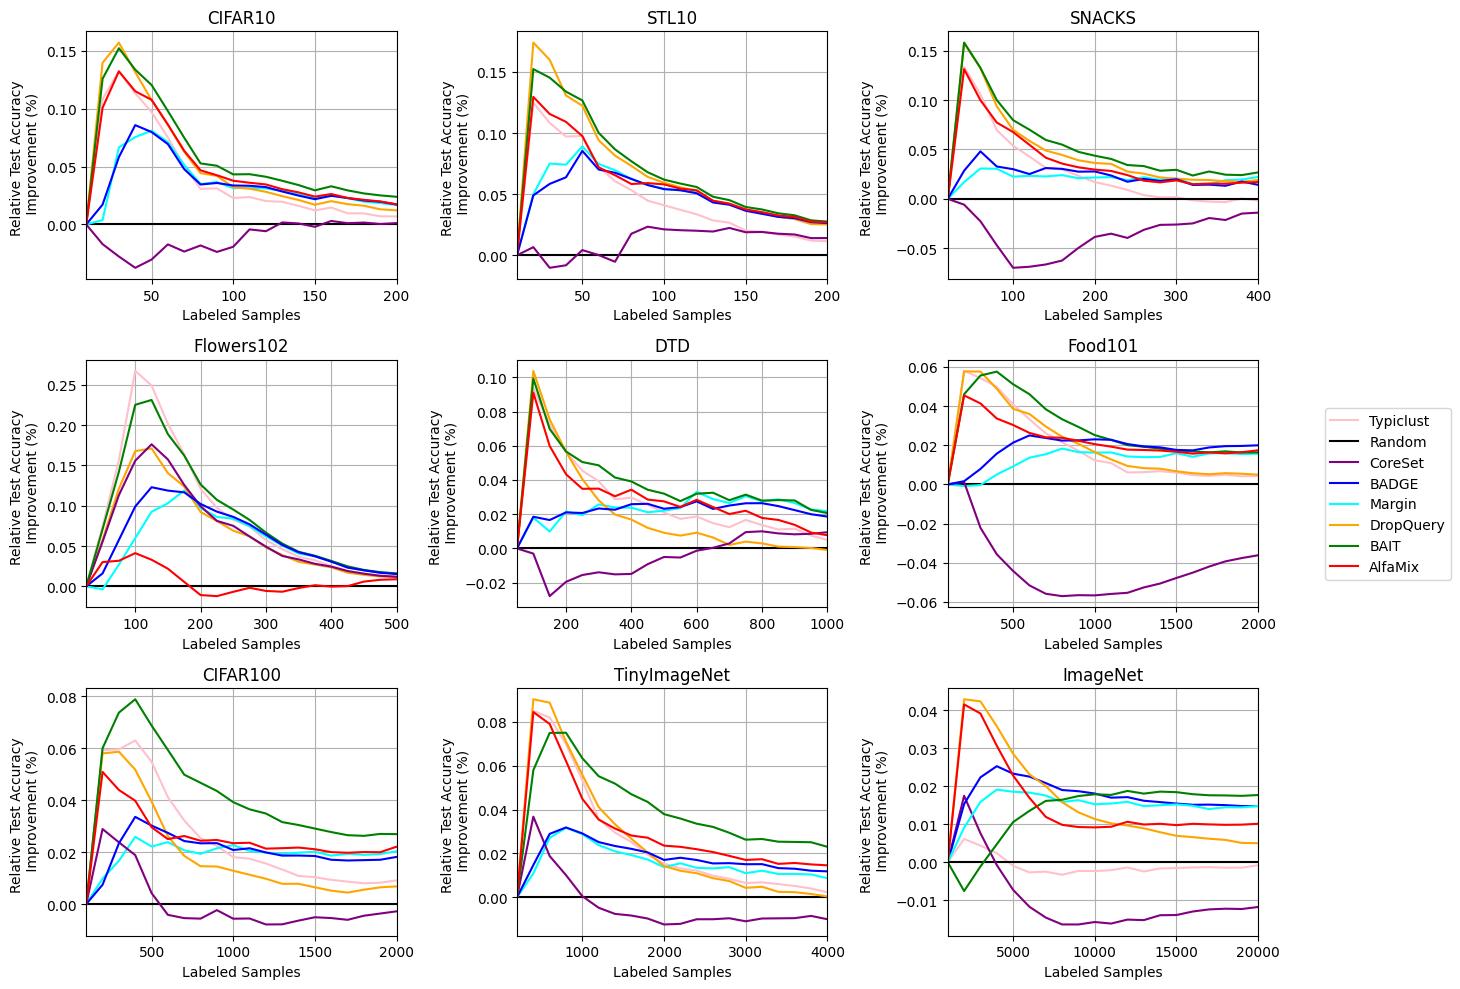

In [3]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(13, 10), tight_layout=True)

for i, dset in enumerate(datasets):
    plt.axes(ax[i//3][i%3])
    n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
    for qs in all_acc_curves_strategies[dset]:
        plt.plot(n_labeled_samples, np.mean(all_acc_curves_strategies[dset][qs], axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0), c=query_strategies[qs]['c'], label=query_strategies[qs]['n'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Relative Test Accuracy \n Improvement (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.125, .5], handles=handles, labels=labels)
plt.show()

## Experiment 2 - Oracle Variations and Number of Batches Ablation

The second experiment investigates different variants of the oracle strategy and additionally tests them for different number of batches per cycle to investigate.

Oracle_Variants = [Naive, Lazy, Intelligent but Lazy]

Batch_Sizes = [11, 55, 110]

In [5]:
experiment_name = 'experiment_2'
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'badge', 'coreset', 'margin', 'typiclass', 'loss', 'dropqueryclass']
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 3 * 3)) # n_dsets * n_seeds * n_oracles * n_batches

for run in runs_strategies:
    key = ('lazy' if 'typiclust' in run.data.params['al.optimal.strategies'] else 'naive') + ('+vary ' if run.data.params['al.optimal.vary_strat_subset_size'] == 'True' else ' ') + 'oracle' + '('+ run.data.params['al.optimal.num_batches'] +')'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_2 #####################################
Found 180 experiments for experiment_2 with expected 180 experiments.
Issue with naive oracle(110) dtd Seed_2


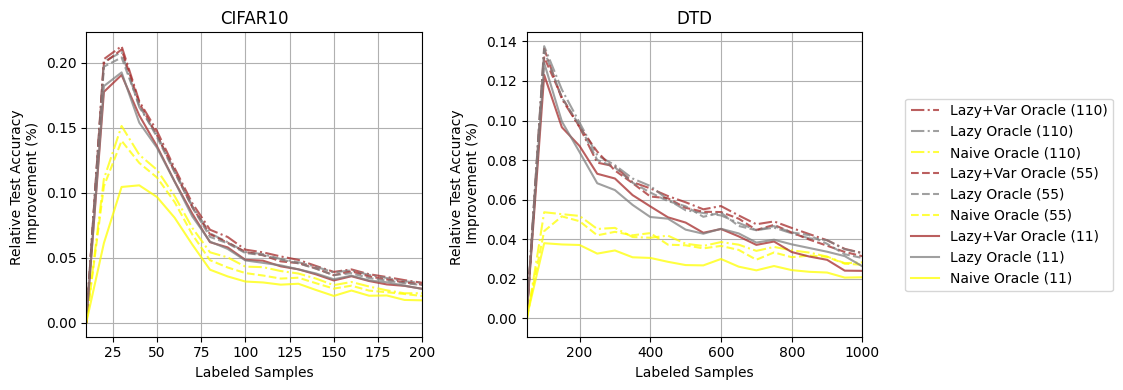

In [5]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), tight_layout=True)

for i, dset in enumerate(['cifar10', 'dtd']):
    plt.axes(ax[i])
    n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
    for qs in all_acc_curves_strategies[dset]:
        if 'oracle' in qs:
            plt.plot(n_labeled_samples, np.mean(all_acc_curves_strategies[dset][qs], axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0), alpha=.75, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle='-' if '11)' in qs else ('--' if '55' in qs else '-.'))
    plt.xlabel('Labeled Samples')
    plt.ylabel('Relative Test Accuracy \n Improvement (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.25, .5], handles=handles, labels=labels)
plt.show()

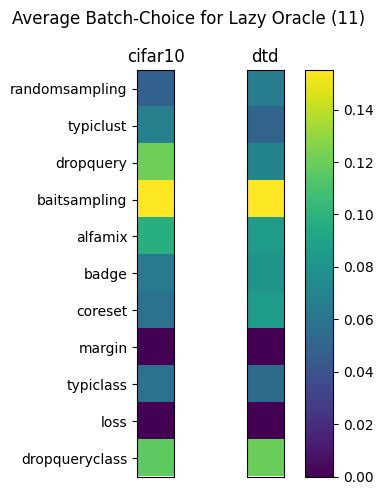

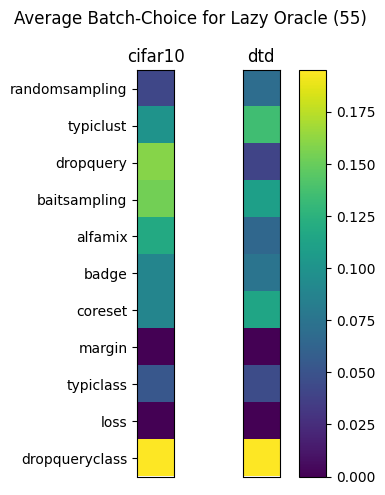

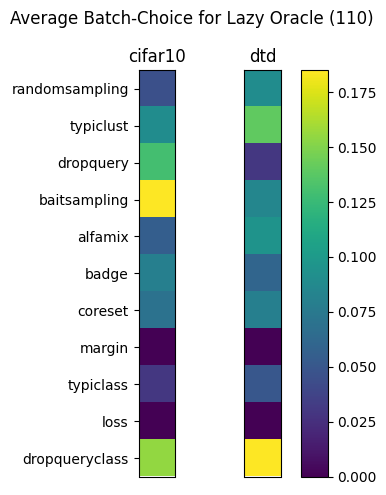

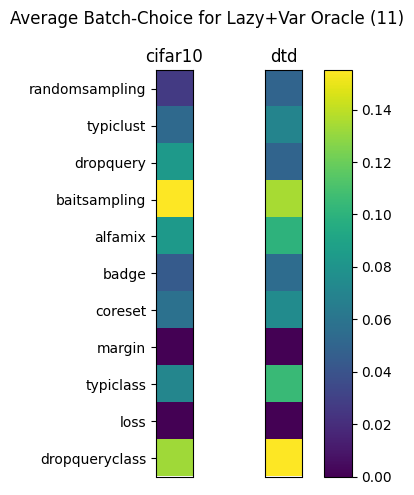

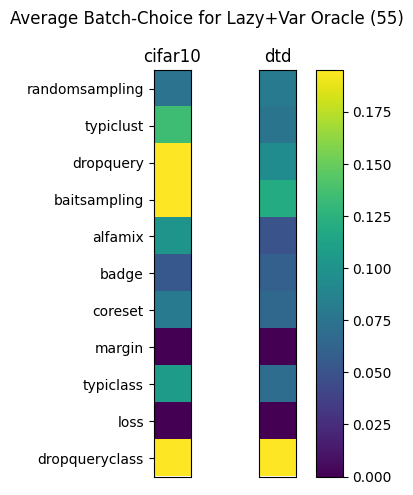

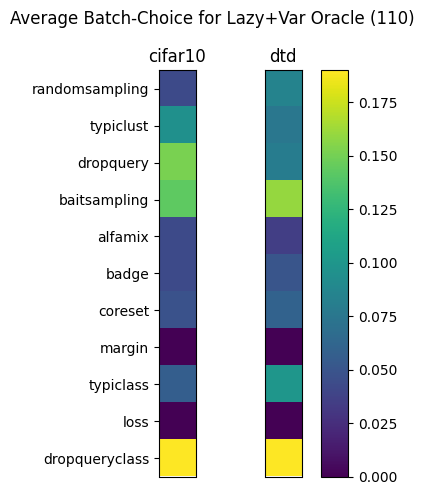

In [6]:
cmap = 'viridis'
n_queries = 20

for strat in ['lazy oracle(11)', 'lazy oracle(55)', 'lazy oracle(110)', 'lazy+vary oracle(11)', 'lazy+vary oracle(55)', 'lazy+vary oracle(110)']:
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(4, 5), width_ratios=[1, 1, .2])
    fig.suptitle("Average Batch-Choice for "+query_strategies[strat]['n'])
    j = 0
    vmin, vmax = 1, 0
    for dset in ['cifar10', 'dtd']:
        query_size = datasets[dset]['qs']
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                im = []
                if seed < len(all_pick_choices[dset][strat]):
                    for i in range(n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
            image.append(img)
        image = np.array(image)
        img = np.mean(image, axis=1)
        img_avg = np.mean(img, axis=-1, keepdims=True)

        vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

        c1 = ax[j].imshow(img_avg)
        ax[j].set_xticks([])
        if j == 0:
            ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
        else:
            ax[j].set_yticks([])
        ax[j].set_title(dset)

        j += 1

    fig.colorbar(c1, cax=ax[-1])
    plt.tight_layout()
    plt.show()

## Experiment 3 - Influence of Number of Acquisitions per Cycle.

This experiment demonstrates the change in performance when increasing the acq_size while keeping the total number of acquisitions over the experiment constant. 

We only use the strategy lazy+vary oracle(110) as it is the strongest performer.

Num_Acqs = [10, 20, 40]

Datasets = [CIFAR10, STL10]

In [7]:
experiment_name = 'experiment_3'
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'badge', 'coreset', 'margin', 'typiclass', 'loss', 'dropqueryclass']
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 3)) # n_dsets * n_seeds * n_acq_sizes

for run in runs_strategies:
    key = f'Lazy+Vary Oracle (acq_size = '+run.data.params['al.acq_size']+')'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_3 #####################################
Found 60 experiments for experiment_3 with expected 60 experiments.


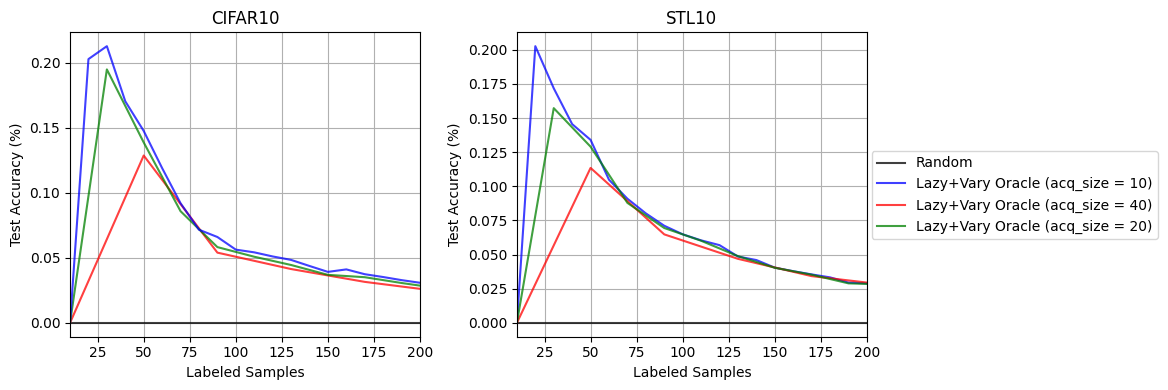

In [8]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), tight_layout=True)

for i, dset in enumerate(['cifar10', 'stl10']):
    plt.axes(ax[i])
    for qs in all_acc_curves_strategies[dset]:
        if 'acq_size' in qs or qs == 'random':
            n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(0, 21, 1 if ('10' in qs or qs == 'random') else (2 if '20' in qs else 4))]
            rand_values = np.array([np.mean(all_acc_curves_strategies[dset]['random'], axis=0)[j] for j in range(0, 21, 1 if ('10' in qs or qs == 'random') else (2 if '20' in qs else 4))])
            plt.plot(n_labeled_samples, np.mean(all_acc_curves_strategies[dset][qs], axis=0) - rand_values, alpha=.75, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Test Accuracy (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.3, .5], handles=handles, labels=labels)
plt.show()

## Experiment 4 - Performance Estimation

In this experiment, we investigate the influence of the performance metric used for evaluating the different batches.

Perf_Est = [Cross Entropy, 0/1 Loss, Brier Score]

In [9]:
experiment_name = 'experiment_4'
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'badge', 'coreset', 'margin', 'typiclass', 'loss', 'dropqueryclass']
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 3)) # n_dsets * n_seeds * n_loss_fn

for run in runs_strategies:
    key = f'Lazy+Vary Oracle (perf_est = '+run.data.params['al.optimal.loss']+')'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_4 #####################################
Found 60 experiments for experiment_4 with expected 60 experiments.


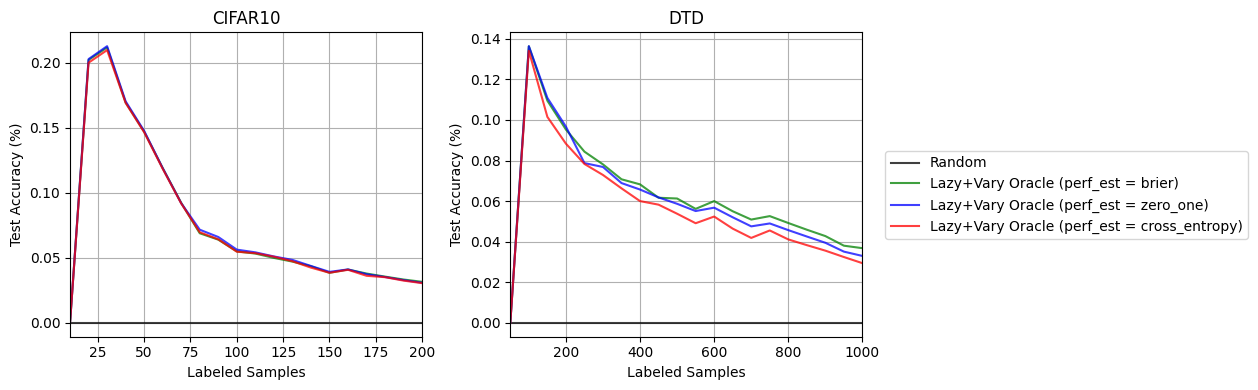

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), tight_layout=True)

for i, dset in enumerate(['cifar10', 'dtd']):
    plt.axes(ax[i])
    for qs in all_acc_curves_strategies[dset]:
        if 'perf_est' in qs or qs == 'random':
            n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(0, 21, 1)]
            plt.plot(n_labeled_samples, np.mean(all_acc_curves_strategies[dset][qs], axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0), alpha=.75, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Test Accuracy (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.4, .5], handles=handles, labels=labels)
plt.show()

## Experiment 5 - Retraining Process

This experiment investigates wether using bayesian updates instead of retraining the model from scratch can serve as a good performance estimator, making the oracle more efficient.

In [ ]:
experiment_name = 'experiment_5'
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'badge', 'coreset', 'margin', 'typiclass', 'loss', 'dropqueryclass']
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 2)) # n_dsets * n_seeds * n_retrain_methods

for run in runs_strategies:
    key = f'Lazy+Vary Oracle (train = '+run.data.params['al.optimal.retraining']+')'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_5 #####################################
Found 40 experiments for experiment_5 with expected 60 experiments.


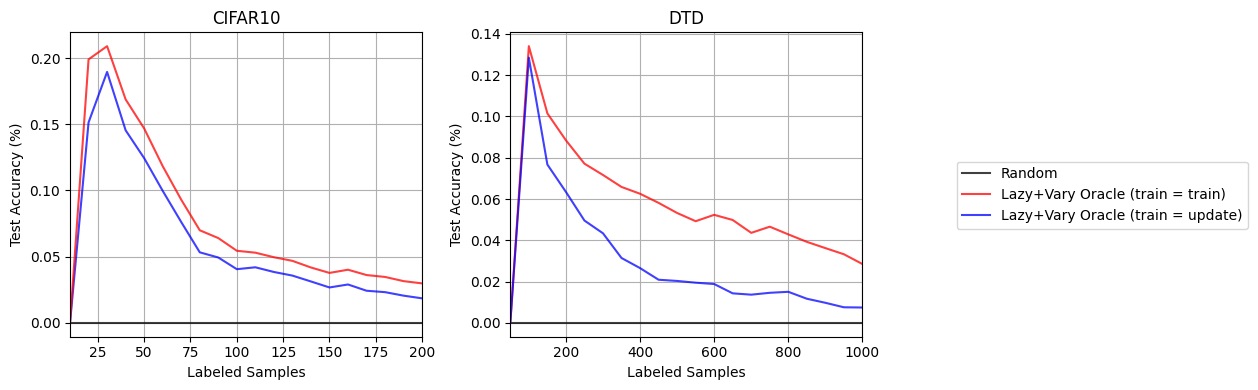

In [13]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), tight_layout=True)

for i, dset in enumerate(['cifar10', 'dtd']):
    plt.axes(ax[i])
    for qs in all_acc_curves_strategies[dset]:
        if 'train' in qs or qs == 'random':
            n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(0, 21, 1)]
            plt.plot(n_labeled_samples, np.mean(all_acc_curves_strategies[dset][qs], axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0), alpha=.75, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Test Accuracy (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.4, .5], handles=handles, labels=labels)
plt.show()

## Experiment 6 - Reduced Number of selection strategies

This experiment investigates wether reducing the number of selection strategies to the most often used increases performance.

The strategies used were [Random, Typiclust, DropQuery, BAIT, DropQueryClass]

In [6]:
experiment_name = 'experiment_6'
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'badge', 'coreset', 'margin', 'typiclass', 'loss', 'dropqueryclass']
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 3)) # n_dsets * n_seeds * n_batches

for run in runs_strategies:
    n_bat = run.data.params['al.optimal.num_batches']
    key = f'lazy+vary+red oracle({n_bat})'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_6 #####################################
Found 60 experiments for experiment_6 with expected 60 experiments.


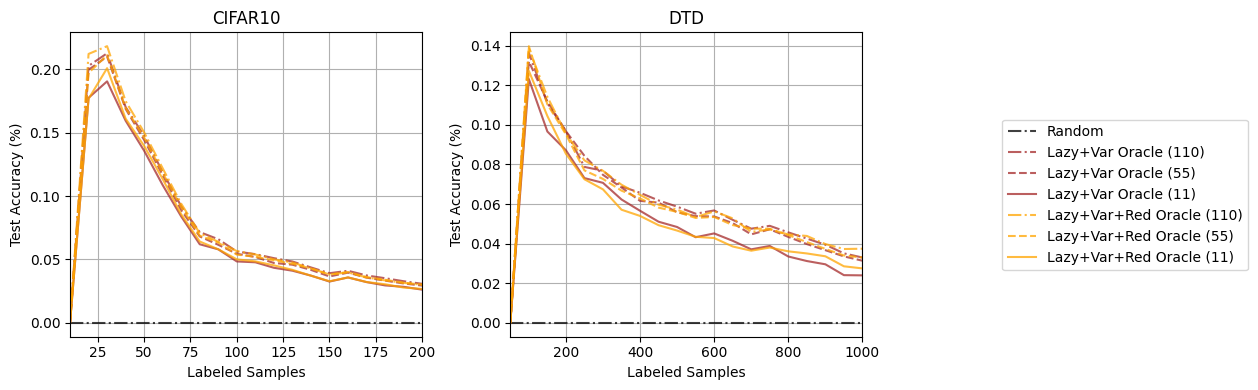

In [15]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), tight_layout=True)

for i, dset in enumerate(['cifar10', 'dtd']):
    plt.axes(ax[i])
    for qs in all_acc_curves_strategies[dset]:
        if 'lazy+var' in qs or qs == 'random':
            n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(0, 21, 1)]
            plt.plot(n_labeled_samples, np.mean(all_acc_curves_strategies[dset][qs], axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0), alpha=.75, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle='-' if '11)' in qs else ('--' if '55' in qs else '-.'))
    plt.xlabel('Labeled Samples')
    plt.ylabel('Test Accuracy (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.4, .5], handles=handles, labels=labels)
plt.show()

## Experiment 7 - Reduced number of selection strategies AND number of batches per cycle

This is similar to exp. 6 with the difference, that we reduce the number of batches to lower amounts in order to see, if it can be more efficient.

Selection Strategies = Random, TypiClust, DropQuery, BAIT, DropClass

Num Batches = 5, 25, 50

In [3]:
experiment_name = 'experiment_7'
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'badge', 'coreset', 'margin', 'typiclass', 'loss', 'dropqueryclass']
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 3)) # n_dsets * n_seeds * n_batches

for run in runs_strategies:
    n_bat = run.data.params['al.optimal.num_batches']
    key = f'lazy+vary+red oracle({n_bat})'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_7 #####################################
Found 60 experiments for experiment_7 with expected 60 experiments.


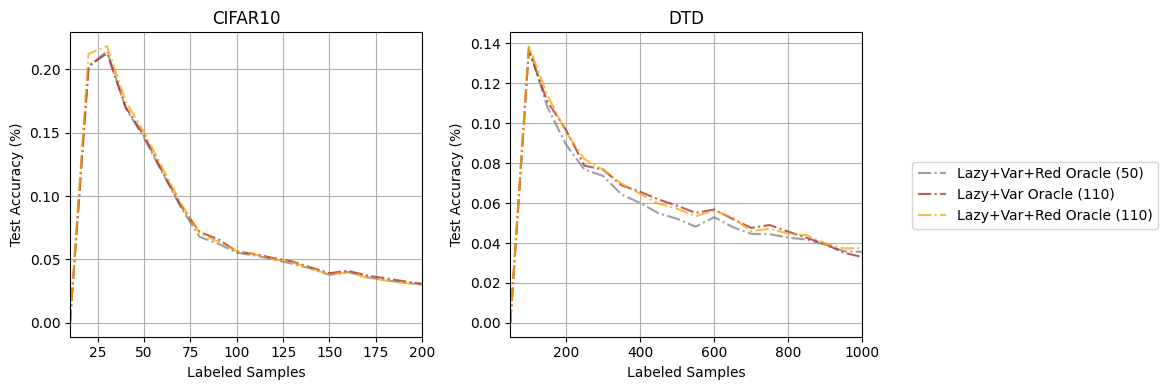

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), tight_layout=True)

for i, dset in enumerate(['cifar10', 'dtd']):
    plt.axes(ax[i])
    for qs in all_acc_curves_strategies[dset]:
        if 'lazy+var' in qs or qs == 'random':
            if '110' in qs or '50' in qs:
                n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(0, 21, 1)]
                plt.plot(n_labeled_samples, np.mean(all_acc_curves_strategies[dset][qs], axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0), alpha=.75, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle='-' if '11)' in qs else ('--' if '55' in qs else '-.'))
    plt.xlabel('Labeled Samples')
    plt.ylabel('Test Accuracy (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.3, .5], handles=handles, labels=labels)
plt.show()